In [7]:
!pip install lime shap -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [8]:
# Install & Imports
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib
import shap

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [9]:
# Mount Drive & Paths
from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/Machine_Learning/Research_base_Model"

CNN_MODEL_PATH      = f"{BASE}/final_cnn_model.h5"
FEATURE_MODEL_PATH  = f"{BASE}/feature_extractor.h5"
SCALER_PATH         = f"{BASE}/feature_scaler.pkl"
RF_PATH             = f"{BASE}/cnn_rf_model.pkl"
SVM_PATH            = f"{BASE}/cnn_svm_model.pkl"
KNN_PATH            = f"{BASE}/cnn_knn_model.pkl"

IMG_SIZE = (224,224)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
# Load All Models (UPDATED)
# Load CNN
cnn_model = load_model(CNN_MODEL_PATH)
print("✅ CNN model loaded")

# Load Feature Extractor
feature_model = load_model(FEATURE_MODEL_PATH)
print("✅ Feature extractor loaded")

# Load scaler
scaler = joblib.load(SCALER_PATH)

# Load ML classifiers
rf  = joblib.load(RF_PATH)
svm = joblib.load(SVM_PATH)
knn = joblib.load(KNN_PATH)

print("✅ RF, SVM, KNN loaded")


✅ CNN model loaded


✅ Feature extractor loaded


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.5.2 when using version 1.6.1. This might lead to b

✅ RF, SVM, KNN loaded


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsClassifier from version 1.5.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


#🔥 GRAD-CAM (UPDATED – works with saved CNN)

In [11]:
# Grad-CAM Function
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, preds = grad_model(img_array)
        class_idx = tf.argmax(preds[0])
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap)
    return heatmap.numpy()


In [12]:
# Grad-CAM Visualization
def show_gradcam(img_path, heatmap):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)

    heatmap = cv2.resize(heatmap, IMG_SIZE)
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

    plt.figure(figsize=(10,4))
    plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img); plt.axis("off")
    plt.subplot(1,3,2); plt.title("Grad-CAM"); plt.imshow(heatmap); plt.axis("off")
    plt.subplot(1,3,3); plt.title("Overlay"); plt.imshow(overlay); plt.axis("off")
    plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


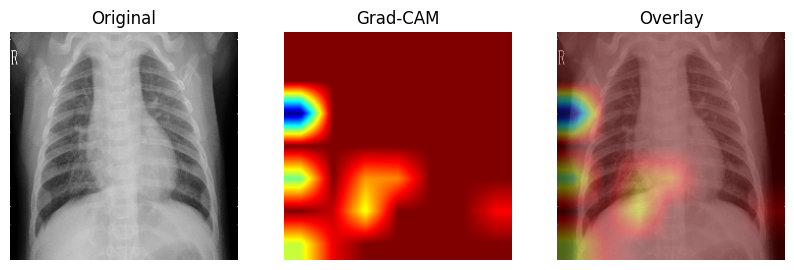

In [13]:
# Run Grad-CAM
img_path = "/content/drive/MyDrive/Machine_Learning/Research_base_Model/chest_xray_dataset/train/PNEUMONIA/person1000_virus_1681.jpeg"

img = image.load_img(img_path, target_size=IMG_SIZE)
x = image.img_to_array(img) / 255.0
x = np.expand_dims(x, axis=0)

# ⚠️ last conv layer name (adjust if needed)
heatmap = make_gradcam_heatmap(x, cnn_model, "conv2d_5")
show_gradcam(img_path, heatmap)


#🧪 LIME (UPDATED)

In [14]:
# LIME CNN Wrapper
def cnn_predict(images):
    images = images / 255.0
    preds = cnn_model.predict(images)
    return np.concatenate([1-preds, preds], axis=1)

  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 740ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 769ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 532ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 500ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 509ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 912ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 798ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 889ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 819ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 486ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 475ms/

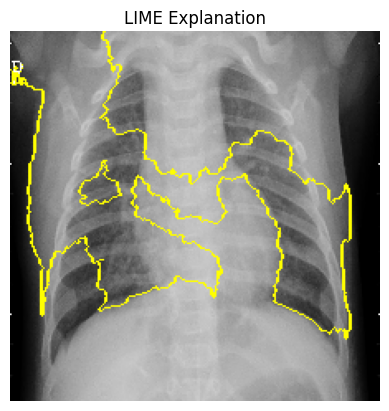

In [33]:
# Run LIME
lime_explainer = lime_image.LimeImageExplainer()

explanation = lime_explainer.explain_instance(
    x[0],
    cnn_predict,
    top_labels=1,
    num_samples=1000
)

temp, mask = explanation.get_image_and_mask(
    explanation.top_labels[0],
    positive_only=True,
    num_features=10
)

plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.axis("off")
plt.show()

#📊 SHAP (UPDATED – uses feature extractor)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step


  0%|          | 0/1 [00:00<?, ?it/s]

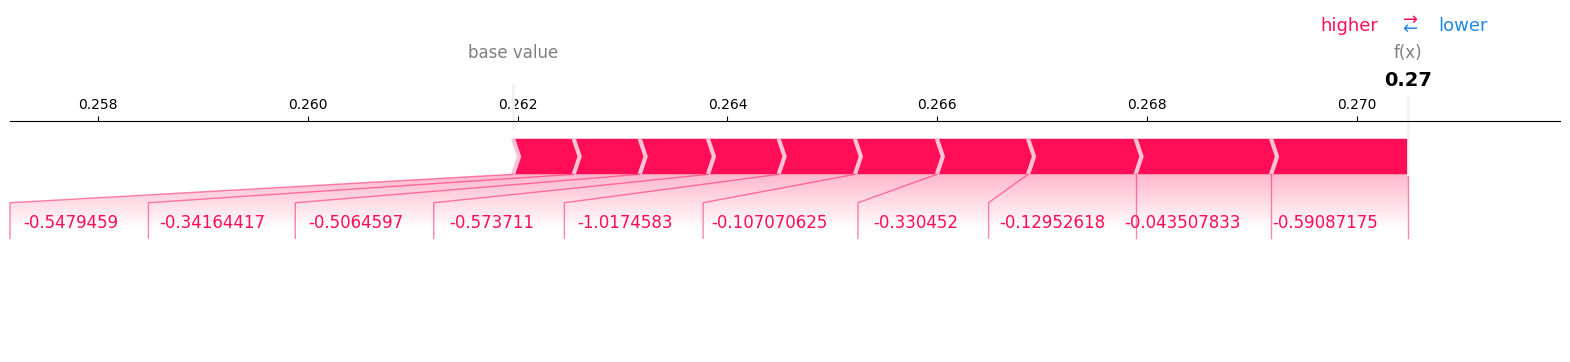

In [55]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import joblib
import shap

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from lime import lime_image
from skimage.segmentation import mark_boundaries

# SHAP Explanation (SVM / RF)
# Extract features
feat = feature_model.predict(x)
feat_scaled = scaler.transform(feat)

background = np.random.rand(50, feat_scaled.shape[1])

shap_explainer = shap.KernelExplainer(svm.predict_proba, background)
shap_values = shap_explainer.shap_values(feat_scaled)

# The error indicates that shap_values (and likely shap_explainer.expected_value)
# has a primary dimension of size 1, meaning index 1 is out of bounds.
# Based on the kernel state, shap_values is an ndarray like `(1, num_features, 2)`.
# For `shap.force_plot`, `shap_values` should be a 1D array `(num_features,)`.
# We access `shap_values[0]` to get `(num_features, 2)`, and then
# select the column for the class we are interested in (e.g., the second column, index 1, for positive class).
# For shap_explainer.expected_value, if it's a 1D array of size 1, access index 0.

plot_expected_value = shap_explainer.expected_value[0] # Access the first (and likely only) expected value
plot_shap_values = shap_values[0][:, 1] # Access the first set of SHAP values, and then the second column for positive class

shap.force_plot(
    plot_expected_value,
    plot_shap_values,
    feat_scaled[0],
    matplotlib=True
)

In [54]:
from PIL import Image
import os

def user_predict_and_explain(img_path):

    print("🖼️ Image Path:", img_path)
    print("="*60)

    if not os.path.exists(img_path):
        print("❌ Image not found")
        return

    # Load image safely
    img = Image.open(img_path).convert("RGB")
    img = img.resize(IMG_SIZE)

    plt.imshow(img)
    plt.title("Input Chest X-ray")
    plt.axis("off")
    plt.show()

    # Preprocess
    x = np.array(img).astype("float32") / 255.0
    x = np.expand_dims(x, axis=0)

    # CNN prediction
    cnn_prob = cnn_model.predict(x)[0][0]
    cnn_pred = int(cnn_prob >= 0.5)

    # Feature extraction
    feat = feature_model.predict(x)
    feat_scaled = scaler.transform(feat)

    # ML predictions
    rf_pred  = rf.predict(feat)[0]
    svm_pred = svm.predict(feat_scaled)[0]
    knn_pred = knn.predict(feat_scaled)[0]

    # Majority voting
    votes = [cnn_pred, rf_pred, svm_pred, knn_pred]
    final_pred = 1 if votes.count(1) >= 2 else 0

    # Print results
    print("📊 MODEL PREDICTIONS")
    print(f"CNN : {'PNEUMONIA' if cnn_pred else 'NORMAL'} (prob={cnn_prob:.4f})")
    print(f"RF  : {'PNEUMONIA' if rf_pred else 'NORMAL'}")
    print(f"SVM : {'PNEUMONIA' if svm_pred else 'NORMAL'}")
    print(f"KNN : {'PNEUMONIA' if knn_pred else 'NORMAL'}")
    print("-"*40)
    print("🩺 FINAL DECISION:")
    print("🔥 PNEUMONIA DETECTED" if final_pred else "✅ NORMAL")

    # ---------------- GRAD-CAM ----------------
    print("\n🔍 Grad-CAM Explanation")
    heatmap = make_gradcam_heatmap(x, cnn_model, "conv2d_5")
    show_gradcam(img_path, heatmap)

    # ---------------- LIME ----------------
    print("\n🧩 LIME Explanation")

    explanation = lime_explainer.explain_instance(
        x[0],
        cnn_predict,
        top_labels=1,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=10
    )

    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME Explanation")
    plt.axis("off")
    plt.show()

    # ---------------- SHAP ----------------
    print("\n📊 SHAP Explanation")
    shap_values = shap_explainer.shap_values(feat_scaled)

    # Correct indexing for shap.force_plot
    plot_expected_value = shap_explainer.expected_value[0] # Access the first (and likely only) expected value
    plot_shap_values = shap_values[0][:, 1] # Access the first set of SHAP values, and then the second column for positive class

    shap.force_plot(
        plot_expected_value,
        plot_shap_values,
        feat_scaled[0],
        matplotlib=True
    )

In [49]:
background = np.random.rand(50, 64)
shap_explainer = shap.KernelExplainer(svm.predict_proba, background)

print("✅ SHAP explainer initialized")



✅ SHAP explainer initialized


🖼️ Image Path: /content/drive/MyDrive/Machine_Learning/Research_base_Model/chest_xray_dataset/train/PNEUMONIA/person1000_virus_1681.jpeg


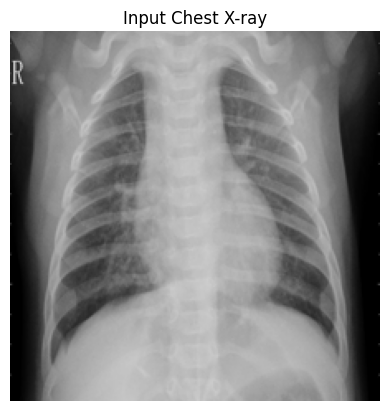

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
📊 MODEL PREDICTIONS
CNN : PNEUMONIA (prob=0.9919)
RF  : PNEUMONIA
SVM : PNEUMONIA
KNN : PNEUMONIA
----------------------------------------
🩺 FINAL DECISION:
🔥 PNEUMONIA DETECTED

🔍 Grad-CAM Explanation


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


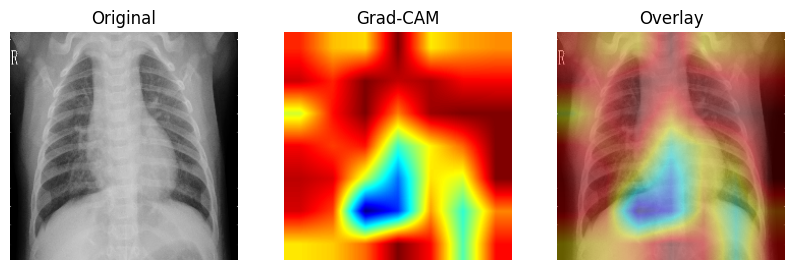


🧩 LIME Explanation


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 553ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 529ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 512ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 507ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 483ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 663ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 970ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 864ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 862ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 682ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 490ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 505ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 493ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 524ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

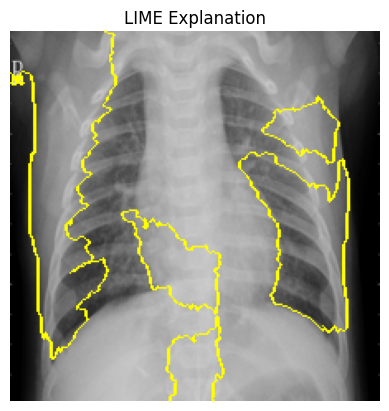


📊 SHAP Explanation


  0%|          | 0/1 [00:00<?, ?it/s]

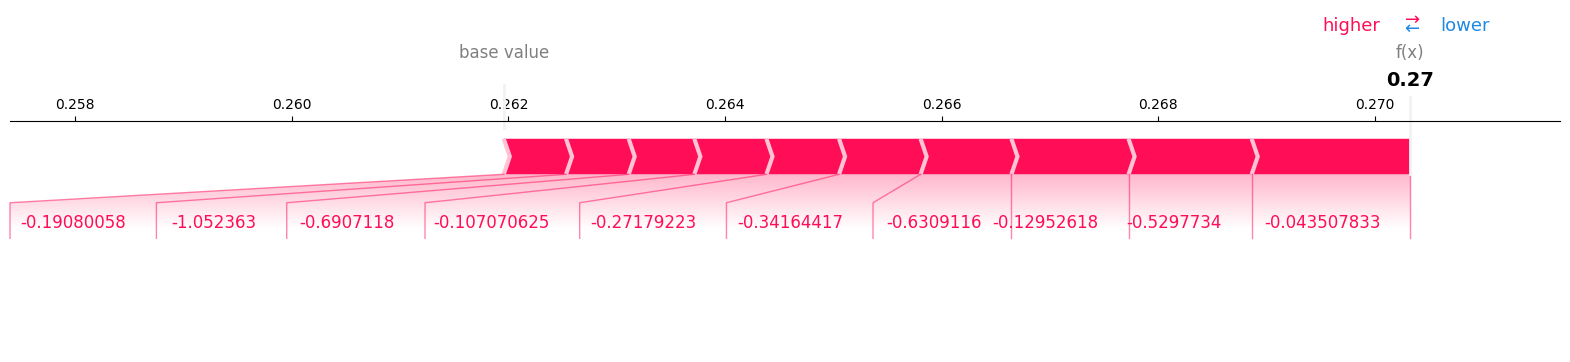

In [56]:
user_predict_and_explain(
 "/content/drive/MyDrive/Machine_Learning/Research_base_Model/chest_xray_dataset/train/PNEUMONIA/person1000_virus_1681.jpeg"
)